# Лабораторная работа: Shapelet Transform

Вам предстоит с нуля реализовать алгоритм Shapelet Transform для извлечения интерпретируемых признаков из временных рядов.

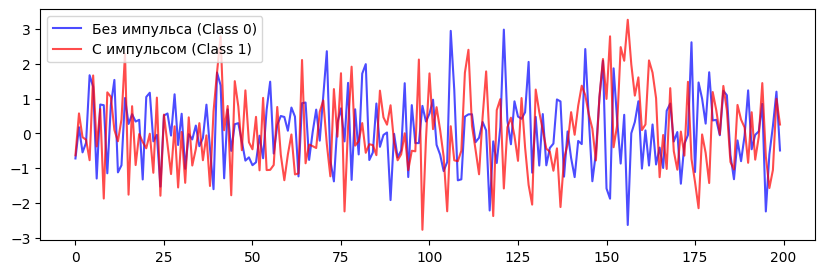

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Any

def generate_synthetic_ts_data(n_samples: int = 50, ts_length: int = 200, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X_class0 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class0 = np.zeros(n_samples // 2, dtype=int)
    X_class1 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class1 = np.ones(n_samples // 2, dtype=int)
    for i in range(n_samples // 2):
        impulse_len = np.random.randint(15, 30)
        start_idx = np.random.randint(10, ts_length - impulse_len - 10)
        x_impulse = np.linspace(-3, 3, impulse_len)
        X_class1[i, start_idx:start_idx + impulse_len] += np.exp(-0.5 * x_impulse**2) * 2
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])
    indices = np.random.permutation(n_samples)
    return X[indices], y[indices]


X, y = generate_synthetic_ts_data(n_samples=50, ts_length=200, random_state=42)
plt.figure(figsize=(10, 3))
plt.plot(X[y == 0][0], label='Без импульса (Class 0)', color='blue', alpha=0.7)
plt.plot(X[y == 1][0], label='С импульсом (Class 1)', color='red', alpha=0.7)
plt.legend()
plt.show()

## Задание 1. Генерация кандидатов-шейплетов

**Что нужно сделать:**
Напишите функцию `generate_candidates`, которая находит все **уникальные** подпоследовательности (от `min_len` до `max_len`) из списка временных рядов.

**TODO:** Соберите кандидаты в список и верните.

In [2]:
def generate_candidates(ts_list: np.ndarray, min_len: int = 3, max_len: int = 20) -> List[np.ndarray]:
    candidates = []
    for ts in ts_list:
        ts_length = len(ts)
        for length in range(min_len, max_len + 1):
            for start in range(ts_length - length + 1):
                candidates.append(ts[start:start + length])
    return candidates


## Задание 2. Вычисление расстояний

**Что нужно сделать:**
Разработайте функционал для поиска минимального Евклидова расстояния от шейплета до временного ряда.
Обе последовательности (сам шейплет и скользящее «окно» ряда) при сравнении должны пройти `Z-score` нормализацию.

**TODO:** Написать функции `z_normalize` и `calculate_shapelet_distance`.

In [3]:
def z_normalize(ts: np.ndarray) -> np.ndarray:
    mean = np.mean(ts)
    std = np.std(ts)
    if std == 0:
        return np.zeros_like(ts)
    return (ts - mean) / std

def calculate_shapelet_distance(shapelet: np.ndarray, time_series: np.ndarray) -> float:
    shapelet_len = len(shapelet)
    ts_len = len(time_series)

    shapelet_norm = z_normalize(shapelet)

    min_dist = np.inf
    for start in range(ts_len - shapelet_len + 1):
        window = time_series[start:start + shapelet_len]
        window_norm = z_normalize(window)
        dist = np.sqrt(np.sum((shapelet_norm - window_norm) ** 2))
        if dist < min_dist:
            min_dist = dist

    return min_dist


In [4]:
def _entropy(y: np.ndarray) -> float:
    if len(y) == 0: return 0.0
    p = np.sum(y) / len(y)
    if p == 0 or p == 1.0: return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

def calculate_information_gain(distances: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    if len(distances) == 0 or len(np.unique(labels)) < 2: return 0.0, 0.0
    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = labels[sorted_indices]
    best_ig, best_split, initial_entropy, n = 0.0, sorted_distances[0], _entropy(labels), len(labels)
    for i in range(1, n):
        ig = initial_entropy - ((len(sorted_labels[:i])/n) * _entropy(sorted_labels[:i]) + ((n-i)/n) * _entropy(sorted_labels[i:]))
        if ig > best_ig: best_ig, best_split = ig, (sorted_distances[i-1] + sorted_distances[i]) / 2.0
    return best_ig, best_split

## Задание 3. Shapelet Transform и алгоритм классификации

**Что нужно сделать:**
Объедините все функции выше! Найдите `top_k` лучших шейплетов (по максимуму `IG`) и трансформируйте исходный датасет временных рядов `X` в матрицу признаков размерности `(n_samples, top_k)`.
Затем натренируйте Random Forest на полученных табличных данных.

**TODO:** Реализовать `shapelet_transform` и предсказать метки.

image.png

In [17]:
from tqdm import tqdm

def shapelet_transform(X: np.ndarray, y: np.ndarray, top_k: int = 5, n_candidates: int = 400) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    #без сэмплинга будет 20 часов считать дистанции ⬆⬆⬆⬆⬆⬆⬆⬆
    all_candidates = generate_candidates(X)
    if len(all_candidates) > n_candidates:
        indices = np.random.choice(len(all_candidates), n_candidates, replace=False)
        candidates = [all_candidates[i] for i in indices]
    else:
        candidates = all_candidates

    shapelet_scores = []

    for candidate in tqdm(candidates, desc="Оценка кандидатов", unit="шейплет"):
        distances = np.array([calculate_shapelet_distance(candidate, ts) for ts in X])
        ig, threshold = calculate_information_gain(distances, y)
        shapelet_scores.append({
            'shapelet': candidate,
            'ig': ig,
            'threshold': threshold,
            'distances': distances
        })


    shapelet_scores.sort(key=lambda x: x['ig'], reverse=True)
    top_shapelets = shapelet_scores[:top_k]

    features = np.column_stack([s['distances'] for s in top_shapelets])

    return features, top_shapelets
    return features, top_shapelets

Оценка кандидатов: 100%|██████████| 400/400 [02:44<00:00,  2.43шейплет/s]


Форма новых признаков: (50, 5)
Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.70      1.00      0.82         7

    accuracy                           0.80        15
   macro avg       0.85      0.81      0.80        15
weighted avg       0.86      0.80      0.79        15



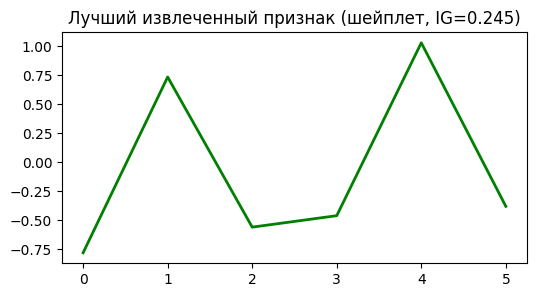

In [19]:
# Итоговое тестирование и Классификация
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

features, top_shapelets = shapelet_transform(X, y, top_k=5)
print(f"Форма новых признаков: {features.shape}")

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

best_shapelet = top_shapelets[0]['shapelet']
plt.figure(figsize=(6, 3))
plt.plot(best_shapelet, color='green', linewidth=2)
plt.title(f"Лучший извлеченный признак (шейплет, IG={top_shapelets[0]['ig']:.3f})")
plt.show()